# Vehicle Dataset from CarDekho

## Dataset Overview
This dataset contains information about used cars listed on CarDekho, one of India's leading car search platforms. It includes details about vehicle specifications, pricing, and ownership history.

**Source:** [Kaggle - Vehicle Dataset from CarDekho](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho)


## Data Dictionary

| Column | Data Type | Description |
|--------|-----------|-------------|
| **name** | object | Complete name and model of the vehicle |
| **year** | int64 | Manufacturing year of the vehicle |
| **selling_price** | int64 | Current selling price (in INR) |
| **km_driven** | int64 | Total kilometers driven by the vehicle |
| **fuel** | object | Fuel type (Petrol, Diesel, CNG, LPG, Electric) |
| **seller_type** | object | Type of seller (Individual, Dealer, Trustmark Dealer) |
| **transmission** | object | Transmission type (Manual, Automatic) |
| **owner** | object | Ownership history (First Owner, Second Owner, etc.) |


## Dataset Statistics
- **Total Records:** 4,340 vehicles
- **Time Period:** Various years (check `year` column for range)
- **No Missing Values:** All columns are complete (4,340 non-null entries)


## Potential Analysis Questions
- What factors most influence vehicle selling price?
- How does depreciation vary by brand, fuel type, or transmission?
- What's the relationship between km_driven and selling_price?
- Which seller types offer better deals?
- How does ownership history affect pricing?

In [ ]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Getting the data - loading Df

In [2]:
vehicles_url = "https://raw.githubusercontent.com/jhlopesalves/data-science-notebooks/refs/heads/main/Python/projects/vehicles/data/CAR%20DETAILS%20FROM%20CAR%20DEKHO.csv"
vehicles = pd.read_csv(vehicles_url, usecols=lambda col: not col.startswith("Unnamed"))

### Data inspection / EDA (Exploratory Data Analysis)

In [3]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


#### Numeric columns

In [4]:
vehicles.select_dtypes("number").describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


### Categorical columns

In [5]:
for col in ["fuel", "seller_type", "transmission", "owner"]:
    display(vehicles[col].value_counts(normalize=True, dropna=False).head(15).round(5))

fuel
Diesel      0.49608
Petrol      0.48917
CNG         0.00922
LPG         0.00530
Electric    0.00023
Name: proportion, dtype: float64

seller_type
Individual          0.74747
Dealer              0.22903
Trustmark Dealer    0.02350
Name: proportion, dtype: float64

transmission
Manual       0.89677
Automatic    0.10323
Name: proportion, dtype: float64

owner
First Owner             0.65253
Second Owner            0.25484
Third Owner             0.07005
Fourth & Above Owner    0.01866
Test Drive Car          0.00392
Name: proportion, dtype: float64

### Target Distribution

In [6]:
sns.set_color_codes("bright")

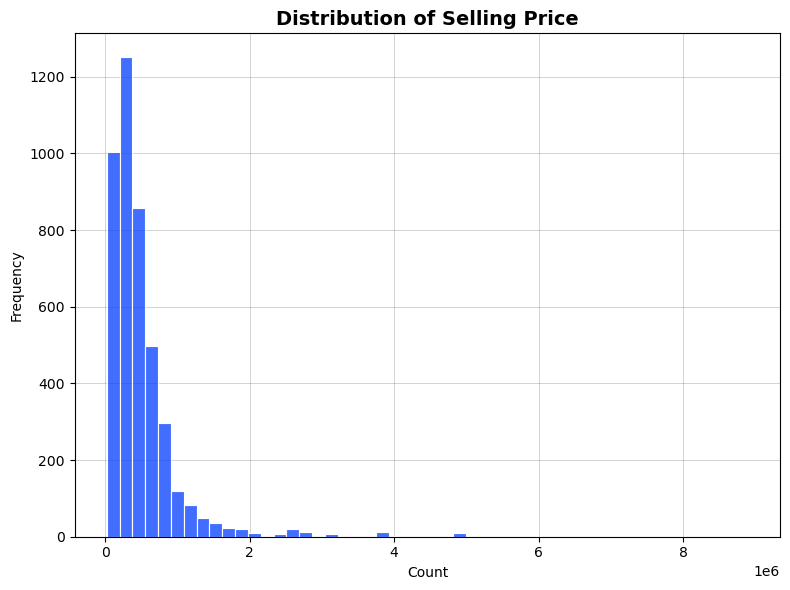

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(
    data=vehicles, x="selling_price", color="b", edgecolor="white", ax=ax, bins=50
)
ax.set(xlabel="Count", ylabel="Frequency")
ax.set_title("Distribution of Selling Price", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.4, linewidth=0.6, color="grey")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Train set / Test set split

In [8]:
from sklearn.model_selection import train_test_split

vehicles_full = vehicles.copy()

X = vehicles_full.drop(columns="selling_price")
y = vehicles_full["selling_price"]

# Stratify the split by binned target to keep the price distribution similar
# in both train and test sets (more stable, fairer offline evaluation).
price_bins = pd.qcut(y, q=10, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=price_bins,
)


#### Plots

In [ ]:
# Create training dataframe by combining X_train and y_train
vehicles_train = X_train.copy()
vehicles_train["selling_price"] = y_train

# Log-transform price (prices are right-skewed; use log1p for zeros)
vehicles_train["log_price"] = np.log1p(vehicles_train["selling_price"])

# Extract brand from name for plots
vehicles_train["brand"] = vehicles_train["name"].str.split().str[0]

# Group rare brands (count < 70) into "OTHER"
brand_counts = vehicles_train["brand"].value_counts()
rare_brands = brand_counts[brand_counts < 100].index
vehicles_train.loc[vehicles_train["brand"].isin(rare_brands), "brand"] = "OTHER"

# Car age = year - 2025
vehicles_train["car_age"] = 2025 - vehicles_train["year"]


# Sort categories by median price (intuitive order)
def median_order(col):
    return (
        vehicles_train.groupby(col)["log_price"]
        .median()
        .sort_values(ascending=False)
        .index
    )


cat_cols = ["brand", "fuel", "seller_type", "transmission", "owner"]
for col in cat_cols:
    vehicles_train[f"{col}_order"] = (
        vehicles_train[col]
        .astype("category")
        .cat.set_categories(median_order(col), ordered=True)
    )

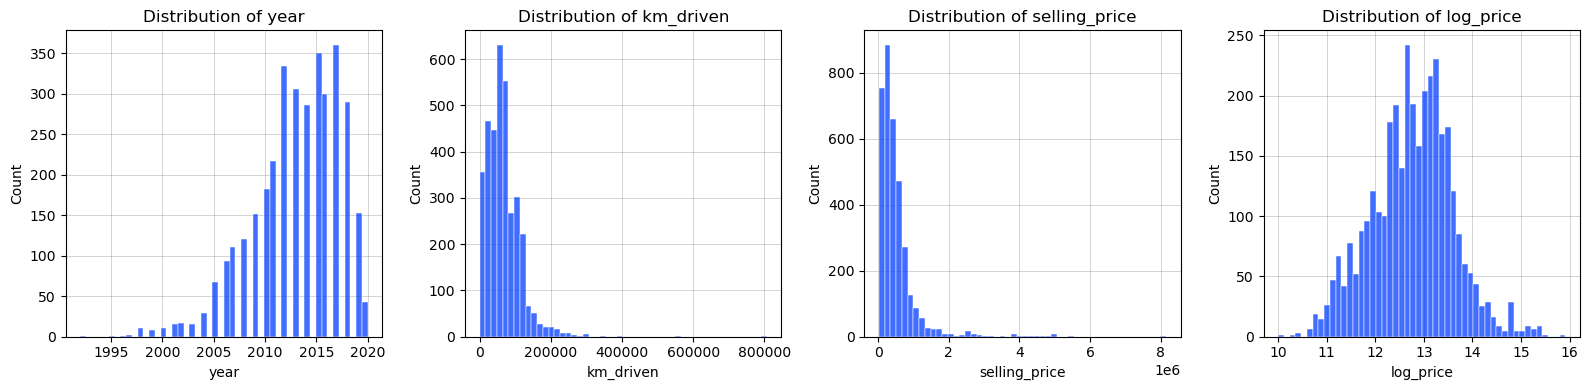

In [10]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))
axes = axes.flatten()

numeric_cols = [
    col
    for col in vehicles_train.select_dtypes("number").columns
    if col in ["year", "selling_price", "km_driven", "log_price"]
]
for i, col in enumerate(numeric_cols):
    sns.histplot(
        data=vehicles_train, x=col, color="b", edgecolor="white", bins=50, ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_ylabel("Count")
    axes[i].set_xlabel(col)
    axes[i].grid(True, alpha=0.4, linewidth=0.6, color="grey")
    axes[i].set_axisbelow(True)


plt.tight_layout()
plt.show()

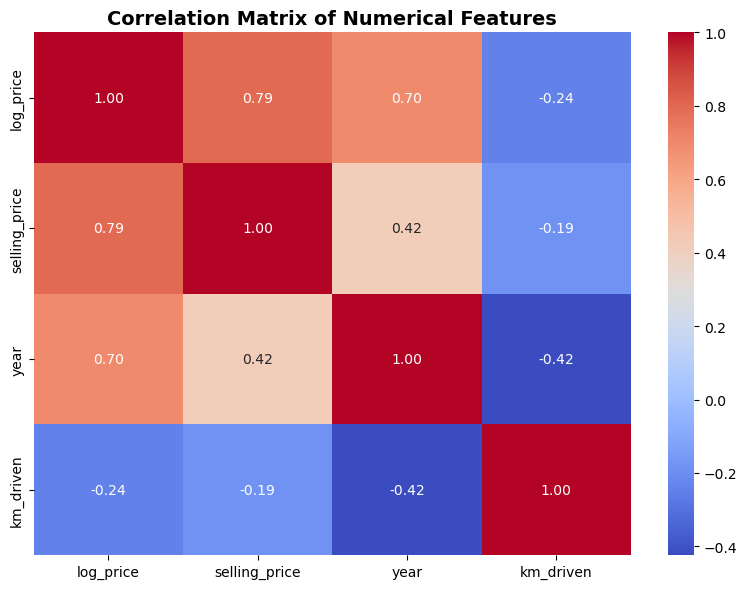

In [11]:
corr_matrix = vehicles_train[["log_price", "selling_price", "year", "km_driven"]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation Matrix of Numerical Features", fontweight="bold", fontsize=14)

plt.tight_layout()
plt.show()

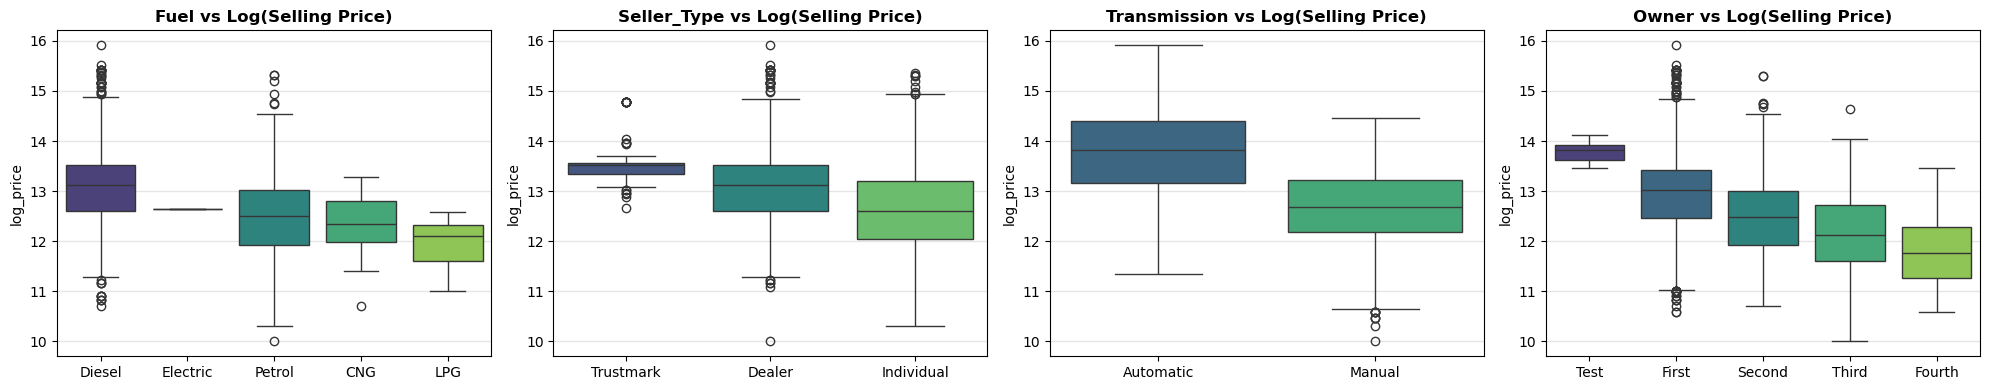

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes = axes.ravel()

for i, col in enumerate(["fuel", "seller_type", "transmission", "owner"]):
    sns.boxplot(
        data=vehicles_train,
        x=col + "_order",
        y="log_price",
        hue=col + "_order",
        palette="viridis",
        ax=axes[i],
        legend=False,
    )
    axes[i].set_title(f"{col.title()} vs Log(Selling Price)", fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].grid(True, axis="y", alpha=0.2, linewidth=1, color="grey")

    # Get current tick labels and modify them
    labels = [label.get_text().split()[0] for label in axes[i].get_xticklabels()]
    axes[i].set_xticks(axes[i].get_xticks())
    axes[i].set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()

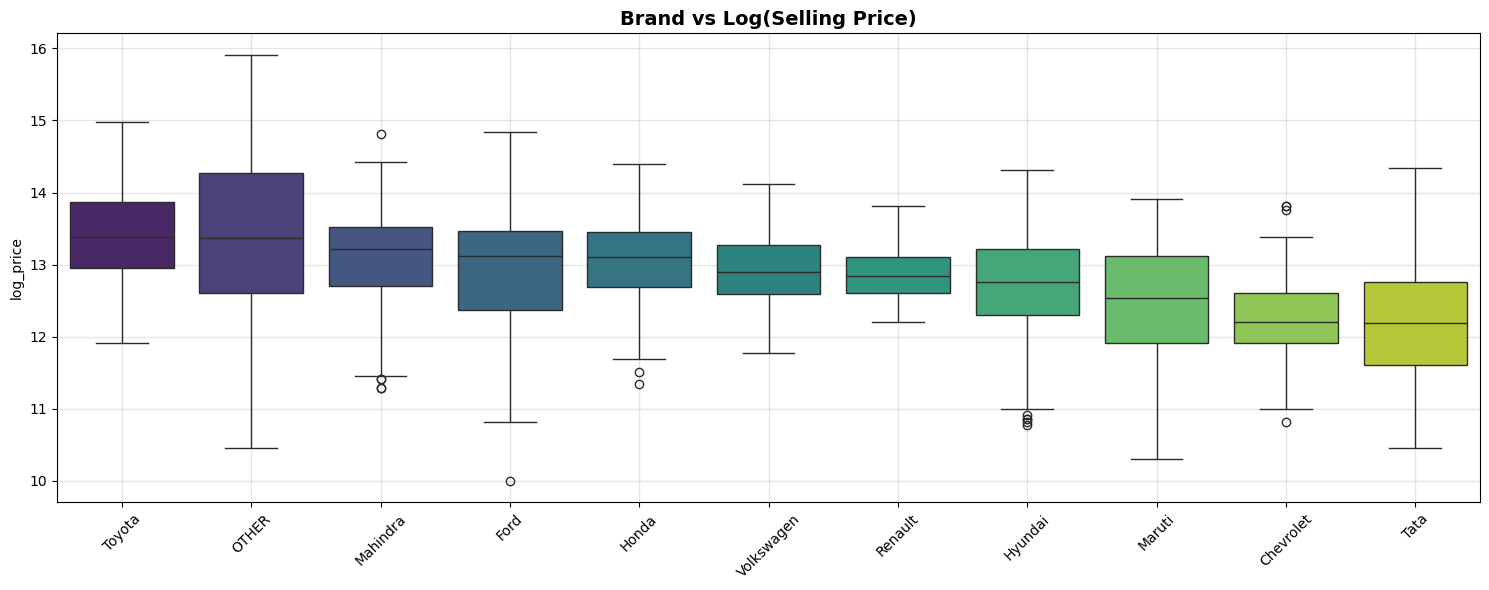

In [13]:
fig, ax = plt.subplots(figsize=(15, 6))

sns.boxplot(
    data=vehicles_train,
    x="brand_order",
    y="log_price",
    hue="brand_order",
    palette="viridis",
    ax=ax,
    legend=False,
)
ax.set_title("Brand vs Log(Selling Price)", fontsize=14, fontweight="bold")
ax.set(xlabel="")
ax.grid(True, alpha=0.2, linewidth=1, color="grey")
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

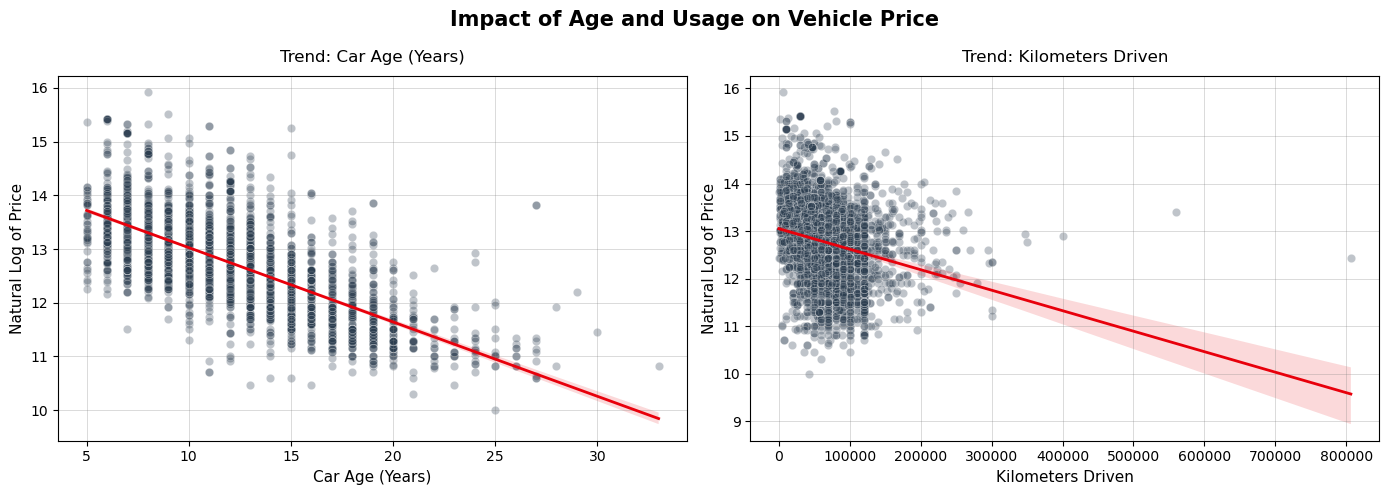

In [14]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(14, 5))
axes = axes.flatten()

# Map column names to readable labels for better presentation
labels = {"car_age": "Car Age (Years)", "km_driven": "Kilometers Driven"}

for i, col in enumerate(["car_age", "km_driven"]):
    # define x as Age (independent) and y as Log Price (dependent).
    sns.scatterplot(
        data=vehicles_train,
        x=col,
        y="log_price",
        color="#2c3e50",
        alpha=0.3,
        edgecolor="white",
        ax=axes[i],
    )

    # This adds the analytical layer: showing the average trend (depreciation).
    sns.regplot(
        data=vehicles_train,
        x=col,
        y="log_price",
        scatter=False,
        color="r",
        line_kws={"linewidth": 2},
        ax=axes[i],
    )

    # Set improved labels and title for each subplot
    axes[i].set_xlabel(labels[col], fontsize=11)
    axes[i].set_ylabel("Natural Log of Price", fontsize=11)

    axes[i].set_title(f"Trend: {labels[col]}", fontsize=12, pad=10)

    axes[i].grid(True, linewidth=0.4, alpha=0.5, color="grey")

# Add a main title for the entire figure
fig.suptitle("Impact of Age and Usage on Vehicle Price", fontsize=15, fontweight="bold")

plt.tight_layout()
plt.show()

In [15]:
order_cols = [col for col in vehicles_train.columns if col.endswith("_order")]
vehicles_train.drop(columns=order_cols, inplace=True)
print(f"Dropped: {order_cols}")

Dropped: ['brand_order', 'fuel_order', 'seller_type_order', 'transmission_order', 'owner_order']


### Transformers / Pipelines 

In [16]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted


# - Linear relationship: each year of age has consistent depreciation impact
class YearToAgeTransformer(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        current_year: int = 2025,
        year_col: str = "year",
        output_col: str = "car_age",
        drop_year: bool = True,
        min_age: int | None = 0,
        max_age: int | None = 50,
    ):
        self.current_year = current_year
        self.year_col = year_col
        self.output_col = output_col
        self.drop_year = drop_year
        self.min_age = min_age
        self.max_age = max_age

    # Fit method: validates input structure and stores metadata for sklearn compatibility
    def fit(self, X, y=None):
        # Ensure input is DataFrame (required for column-based operations)
        if not hasattr(X, "columns"):
            raise TypeError("YearToAgeTransformer expects a pandas DataFrame.")
        # Verify required column exists before transformation
        if self.year_col not in X.columns:
            raise ValueError(f"Column '{self.year_col}' not found in X.")

        # Store original feature names and count for scikit-learn pipeline compatibility
        # Required for feature name propagation through pipelines
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = X.shape[1]
        self.is_fitted_ = True  # Flag for check_is_fitted validation
        return self

    # Transform method: performs the actual year-to-age conversion
    def transform(self, X):
        # Verify transformer was fitted before transform (sklearn protocol)
        check_is_fitted(self, attributes="is_fitted_")
        X = X.copy()  # Avoid modifying original DataFrame

        # Convert to numeric, coercing invalid values to NaN (handles mixed types)
        year = pd.to_numeric(X[self.year_col], errors="coerce")
        car_age = self.current_year - year

        # Apply lower bound clipping (prevents negative ages from future years or data errors)
        if self.min_age is not None:
            car_age = car_age.clip(lower=self.min_age)
        # Apply upper bound clipping (prevents extreme ages from vintage/antique cars)
        if self.max_age is not None:
            car_age = car_age.clip(upper=self.max_age)

        X[self.output_col] = car_age

        # Optionally remove original year column to reduce feature redundancy
        if self.drop_year:
            X = X.drop(columns=[self.year_col])

        return X


# Custom transformer that extracts brand/manufacturer from full car name
# Brand captures manufacturer reputation, pricing tier, and quality perception
# Loses model-specific information; assumes first word is always brand (may fail for edge cases)
class BrandExtractor(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        name_col: str = "name",
        output_col: str = "brand",
        drop_name: bool = True,
        missing_value: str = "__MISSING__",
        *,
        min_count: int | None = None,
        other_value: str = "__OTHER__",
    ):
        self.name_col = name_col
        self.output_col = output_col
        self.drop_name = drop_name
        self.missing_value = missing_value
        self.min_count = min_count
        self.other_value = other_value

    def _extract_brand_series(self, X: pd.DataFrame) -> pd.Series:
        series = (
            X[self.name_col]
            .astype("string")
            .fillna("")
            .str.strip()
            .str.replace(r"\s+", " ", regex=True)
        )

        brand = series.str.split(" ").str[0].fillna(self.missing_value)
        brand = brand.where(brand.ne(""), self.missing_value)
        return brand

    # Fit method: validates DataFrame structure before extraction
    def fit(self, X, y=None):
        if not hasattr(X, "columns"):
            raise TypeError("BrandExtractor expects a pandas DataFrame.")
        if self.name_col not in X.columns:
            raise ValueError(f"Column '{self.name_col}' not found in X.")

        X_df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        brand = self._extract_brand_series(X_df)

        if self.min_count is None or self.min_count <= 1:
            # Keep everything (no grouping)
            self.kept_brands_ = None
        else:
            counts = brand.value_counts(dropna=False)
            kept = counts[counts >= self.min_count].index.astype("string")
            self.kept_brands_ = set(kept.tolist())

        self.feature_names_in_ = np.asarray(X_df.columns, dtype=object)
        self.n_features_in_ = X_df.shape[1]
        self.is_fitted_ = True
        return self

    # Transform method: extracts first word from car name as brand identifier
    def transform(self, X):
        check_is_fitted(self, attributes="is_fitted_")
        X_df = X.copy()

        brand = self._extract_brand_series(X_df)

        # Group rare/unseen brands -> __OTHER__ (but keep __MISSING__ as missing)
        if self.kept_brands_ is not None:
            is_missing = brand.eq(self.missing_value)
            is_kept = brand.isin(self.kept_brands_)
            brand = brand.where(is_missing | is_kept, self.other_value)

        X_df[self.output_col] = brand

        if self.drop_name:
            X_df = X_df.drop(columns=[self.name_col])

        return X_df

In [ ]:
from typing import Callable

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# car age matters more than year
def make_feature_engineering(*, current_year: int = 2025) -> Pipeline:
    return Pipeline(
        steps=[
            # Extract brand from car name - reduces high cardinality and captures brand value
            (
                "brand_extractor",
                BrandExtractor(drop_name=True, min_count=100, other_value="_OTHER_"),
            ),
            # Convert year to age - more intuitive and stationary feature for models
            (
                "year_to_age",
                YearToAgeTransformer(current_year=current_year, drop_year=True),
            ),
        ]
    )


# drop_first=True prevents multicollinearity but loses interpretability of baseline
# sparse_output=False uses more memory but compatible with more estimators
def make_categorical_pipe(
    *, drop_first: bool = True, sparse_output: bool = True
) -> Pipeline:
    return Pipeline(
        steps=[
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="infrequent_if_exist",
                    min_frequency=5,
                    drop="first" if drop_first else None,  # Avoids dummy variable trap
                    sparse_output=sparse_output,  # Dense arrays work better with most sklearn models
                ),
            )
        ]
    )


# Numerical preprocessing pipeline: handles scaling of numerical features
def make_numerical_pipe(*, transformer: TransformerMixin | None = None) -> Pipeline:
    if transformer is None:
        transformer = StandardScaler()
    return Pipeline(steps=[("num", transformer)])


# Column transformer factory: applies different preprocessing to different column types
# Categorical and numerical data require fundamentally different preprocessing
def make_preprocessor(
    *,
    categorical_cols: list[str],
    numerical_cols: list[str],
    categorical_pipe: Pipeline | None = None,
    numerical_pipe: Pipeline | None = None,
    remainder: str = "drop",
) -> ColumnTransformer:
    if categorical_pipe is None:
        categorical_pipe = make_categorical_pipe()
    if numerical_pipe is None:
        numerical_pipe = make_numerical_pipe()

    # ColumnTransformer applies transformers in parallel to different column subsets
    return ColumnTransformer(
        transformers=[
            ("categorical", categorical_pipe, categorical_cols),
            ("numerical", numerical_pipe, numerical_cols),
        ],
        remainder=remainder,  # What to do with columns not specified above
    )


# Chains feature engineering, preprocessing, and modeling
def make_full_pipeline(
    *,
    model: BaseEstimator | None = None,
    current_year: int = 2025,
    categorical_cols: list[str] | None = None,
    numerical_cols: list[str] | None = None,
    preprocessor: ColumnTransformer | None = None,
    feature_engineering: Pipeline | None = None,
) -> Pipeline:
    if model is None:
        model = LinearRegression()

    if categorical_cols is None:
        categorical_cols = ["fuel", "seller_type", "transmission", "owner", "brand"]

    if numerical_cols is None:
        numerical_cols = ["km_driven", "car_age"]

    if feature_engineering is None:
        feature_engineering = make_feature_engineering(current_year=current_year)

    if preprocessor is None:
        preprocessor = make_preprocessor(
            categorical_cols=categorical_cols,
            numerical_cols=numerical_cols,
        )

    # Critical: clone() creates independent copies, preventing state contamination
    # Without clone(), reusing objects can cause fit/transform to use wrong data
    return Pipeline(
        steps=[
            ("feature_engineering", clone(feature_engineering)),  # Domain transforms
            ("preprocessor", clone(preprocessor)),  # Encoding and scaling
            ("model", clone(model)),  # Final estimator
        ]
    )


# Log-transformed target pipeline: handles skewed target distributions
def make_log_target_model(
    *,
    model: BaseEstimator | None = None,
    current_year: int = 2025,
    categorical_cols: list[str] | None = None,
    numerical_cols: list[str] | None = None,
    preprocessor: ColumnTransformer | None = None,
    feature_engineering: Pipeline | None = None,
    func: Callable[[np.ndarray], np.ndarray] = np.log1p,  # log(1+x) handles zeros
    inverse_func: Callable[
        [np.ndarray], np.ndarray
    ] = np.expm1,  # exp(x)-1 inverts log1p
) -> TransformedTargetRegressor:
    # TransformedTargetRegressor wraps any regressor and transforms target before fitting
    # Automatically applies inverse_func to predictions for evaluation on original scale
    # This ensures metrics like RMSE/MAE are computed in currency units, not log-units
    return TransformedTargetRegressor(
        regressor=make_full_pipeline(
            model=model,
            current_year=current_year,
            categorical_cols=categorical_cols,
            numerical_cols=numerical_cols,
            preprocessor=preprocessor,
            feature_engineering=feature_engineering,
        ),
        func=func,  # Applied to y during fit
        inverse_func=inverse_func,  # Applied to predictions for interpretability
    )


In [18]:
tmp = make_feature_engineering().fit_transform(X_train.head())
print(tmp.columns)

Index(['km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'brand',
       'car_age'],
      dtype='object')


### Baseline model

In [19]:
baseline = make_log_target_model()

baseline.fit(X_train, y_train)

,regressor,Pipeline(step...egression())])
,transformer,None
,func,<ufunc 'log1p'>
,inverse_func,<ufunc 'expm1'>
,check_inverse,True
,steps,"[('brand_extractor', ...), ('year_to_age', ...)]"
,transform_input,None
,memory,None
,verbose,False
,name_col,'name'
,output_col,'brand'


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_baseline = baseline.predict(X_test)
r2 = r2_score(y_test, y_pred_baseline)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae = mean_absolute_error(y_test, y_pred_baseline)

print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

R2 Score: 0.5357
RMSE: 456397.5905
MAE: 188885.1268


### Residual Plot

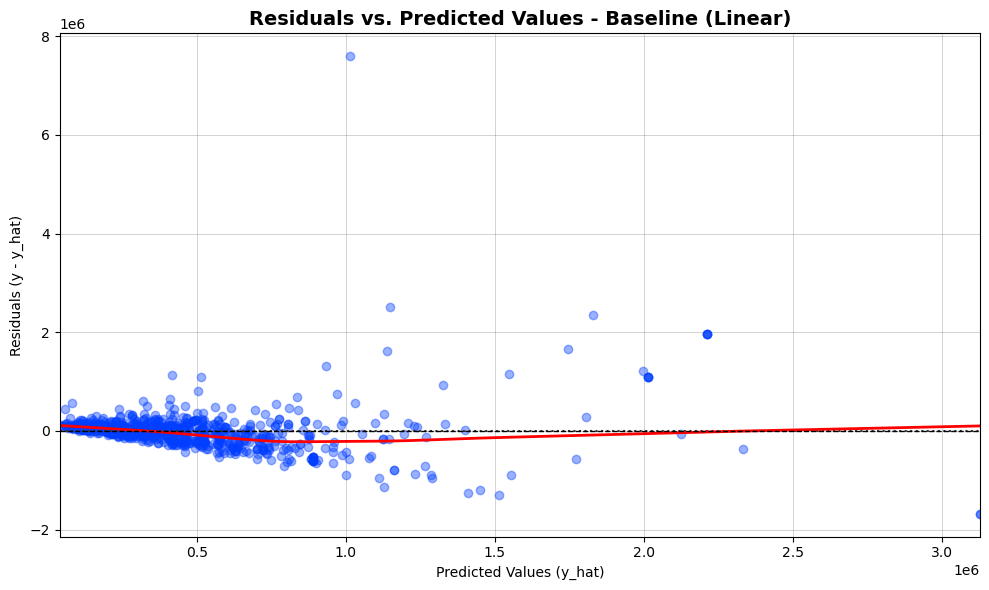

In [21]:
y_pred_flatten = y_pred_baseline.flatten()
y_true_flatten = y_test.values.flatten()

# Calculate residuals
residuals = y_true_flatten - y_pred_flatten

fig, ax = plt.subplots(figsize=(10, 6))

# 4. The Residual Plot
# 'lowess=True' adds the smoothing line to reveal hidden patterns
# 'line_kws' styles that smoothing line (red for visibility)
sns.residplot(
    x=y_pred_flatten,
    y=residuals,
    lowess=True,
    color="b",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red", "lw": 2},
    ax=ax,
)

ax.set_title(
    "Residuals vs. Predicted Values - Baseline (Linear)", fontsize=14, fontweight="bold"
)
ax.set_xlabel("Predicted Values (y_hat)")
ax.set_ylabel("Residuals (y - y_hat)")
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.grid(True, alpha=0.4, linewidth=0.6, color="grey")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Candidate model construction

In [22]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer

categorical_cols = ["fuel", "seller_type", "transmission", "owner", "brand"]
numerical_cols = ["km_driven", "car_age"]

baseline_preprocessor = make_preprocessor(
    categorical_cols=categorical_cols,
    numerical_cols=numerical_cols,
)

poly_num_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ]
)

poly2_preprocessor = make_preprocessor(
    categorical_cols=categorical_cols,
    numerical_cols=numerical_cols,
    numerical_pipe=poly_num_pipe,
)

spline_num_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("splines", SplineTransformer(n_knots=8, degree=3, include_bias=False)),
    ]
)

spline_preprocessor = make_preprocessor(
    categorical_cols=categorical_cols,
    numerical_cols=numerical_cols,
    numerical_pipe=spline_num_pipe,
)

candidates = {
    "baseline_ridge": make_log_target_model(
        model=Ridge(alpha=1.0, random_state=42),
        preprocessor=baseline_preprocessor,
    ),
    "poly2_ridge": make_log_target_model(
        model=Ridge(alpha=1.0, random_state=42),
        preprocessor=poly2_preprocessor,
    ),
    "spline_ridge": make_log_target_model(
        model=Ridge(alpha=1.0, random_state=42),
        preprocessor=spline_preprocessor,
    ),
}


In [23]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer

categorical_cols = ["fuel", "seller_type", "transmission", "owner", "brand"]
numerical_cols = ["km_driven", "car_age"]

baseline_preprocessor = make_preprocessor(
    categorical_cols=categorical_cols,
    numerical_cols=numerical_cols,
)

poly2_preprocessor = make_preprocessor(
    categorical_cols=categorical_cols,
    numerical_cols=numerical_cols,
    numerical_pipe=make_numerical_pipe(
        transformer=Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("poly", PolynomialFeatures(degree=2, include_bias=False)),
            ]
        )
    ),
)

spline_preprocessor = make_preprocessor(
    categorical_cols=categorical_cols,
    numerical_cols=numerical_cols,
    numerical_pipe=make_numerical_pipe(
        transformer=Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("splines", SplineTransformer(n_knots=8, degree=3, include_bias=False)),
            ]
        )
    ),
)

candidates = {
    "baseline_ridge": make_log_target_model(
        model=Ridge(alpha=1.0),
        preprocessor=baseline_preprocessor,
    ),
    "poly2_ridge": make_log_target_model(
        model=Ridge(alpha=1.0),
        preprocessor=poly2_preprocessor,
    ),
    "spline_ridge": make_log_target_model(
        model=Ridge(alpha=1.0),
        preprocessor=spline_preprocessor,
    ),
}

In [24]:
for name, est in candidates.items():
    est.fit(X_train, y_train)
    preds = est.predict(X_test[:5])
    print(name, np.round(preds, 2))

baseline_ridge [207864.97 523549.98 468956.77 402487.18  55969.54]
poly2_ridge [199460.82 502697.57 480805.72 389758.88  66912.32]
spline_ridge [201602.89 508558.92 484964.16 395164.31  64901.99]


In [25]:
from typing import Literal

from sklearn.base import BaseEstimator
from sklearn.model_selection import KFold, RepeatedKFold, cross_validate

SortMetric = Literal["rmse", "mae", "r2"]


def evaluate_candidates(
    candidates: dict[str, BaseEstimator],
    X,
    y,
    *,
    n_splits: int = 5,
    shuffle: bool = True,
    random_state: int = 42,
    n_repeats: int = 1,
    sort_by: SortMetric = "rmse",
    n_jobs: int = -1,
    error_score: float | str = "raise",
    verbose: bool = True,
    return_train_score: bool = False,
    robust_summary: bool = False,
) -> pd.DataFrame:
    """
    Cross-validate candidate regressors and return mean/std for R², RMSE, MAE.

    Notes:
      - Uses shuffled KFold by default (better for non-time-series data).
      - Uses RepeatedKFold when n_repeats > 1 (more stable estimates).
      - RMSE/MAE are returned positive (we flip sklearn's neg_* scorers).
    """
    y_array = np.asarray(y).ravel()

    if n_repeats > 1:
        cv = RepeatedKFold(
            n_splits=n_splits,
            n_repeats=n_repeats,
            random_state=random_state,
        )
    else:
        cv = KFold(
            n_splits=n_splits,
            shuffle=shuffle,
            random_state=random_state if shuffle else None,
        )

    scoring = {
        "r2": "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
    }

    rows: list[dict[str, float | str]] = []

    for name, estimator in candidates.items():
        if verbose:
            print(f"Evaluating {name}...")

        scores = cross_validate(
            estimator,
            X,
            y_array,
            cv=cv,
            scoring=scoring,
            n_jobs=n_jobs,
            error_score=error_score,
            return_train_score=return_train_score,
        )

        def summarise(metric_values: np.ndarray) -> dict[str, float]:
            if robust_summary:
                median = float(np.median(metric_values))
                q1 = float(np.quantile(metric_values, 0.25))
                q3 = float(np.quantile(metric_values, 0.75))
                return {"median": median, "iqr": q3 - q1}
            return {
                "mean": float(metric_values.mean()),
                "std": float(metric_values.std()),
            }

        rmse = -scores["test_rmse"]
        mae = -scores["test_mae"]
        r2 = scores["test_r2"]

        row = {"Model": name}
        row.update({f"R2 ({k})": v for k, v in summarise(r2).items()})
        row.update({f"RMSE ({k})": v for k, v in summarise(rmse).items()})
        row.update({f"MAE ({k})": v for k, v in summarise(mae).items()})

        if return_train_score:
            train_rmse = -scores["train_rmse"]
            train_mae = -scores["train_mae"]
            train_r2 = scores["train_r2"]
            row.update({f"Train R2 ({k})": v for k, v in summarise(train_r2).items()})
            row.update({
                f"Train RMSE ({k})": v for k, v in summarise(train_rmse).items()
            })
            row.update({f"Train MAE ({k})": v for k, v in summarise(train_mae).items()})

        rows.append(row)

    df = pd.DataFrame(rows)

    sort_col = {"rmse": "RMSE (mean)", "mae": "MAE (mean)", "r2": "R2 (mean)"}[sort_by]
    if robust_summary:
        sort_col = {
            "rmse": "RMSE (median)",
            "mae": "MAE (median)",
            "r2": "R2 (median)",
        }[sort_by]

    ascending = sort_by in {"rmse", "mae"}
    df = df.sort_values(sort_col, ascending=ascending).reset_index(drop=True)
    return df


In [26]:
results = evaluate_candidates(
    candidates,
    X_train,
    y_train,
    n_splits=5,
    n_repeats=1,
    n_jobs=1,  # avoid nested parallelism
    sort_by="rmse",
)
display(results)

Evaluating baseline_ridge...


C:\Users\jhonm\.conda\envs\DS\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Evaluating poly2_ridge...


C:\Users\jhonm\.conda\envs\DS\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Evaluating spline_ridge...


C:\Users\jhonm\.conda\envs\DS\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Model,R2 (mean),R2 (std),RMSE (mean),RMSE (std),MAE (mean),MAE (std)
0,poly2_ridge,0.586169,0.073569,352181.033301,52125.087470,171192.061923,11980.518190
1,spline_ridge,0.581106,0.070749,354495.272344,51427.717926,171166.928587,11934.815550
2,baseline_ridge,0.580690,0.070924,354767.539327,52164.883610,170980.724462,12255.981749


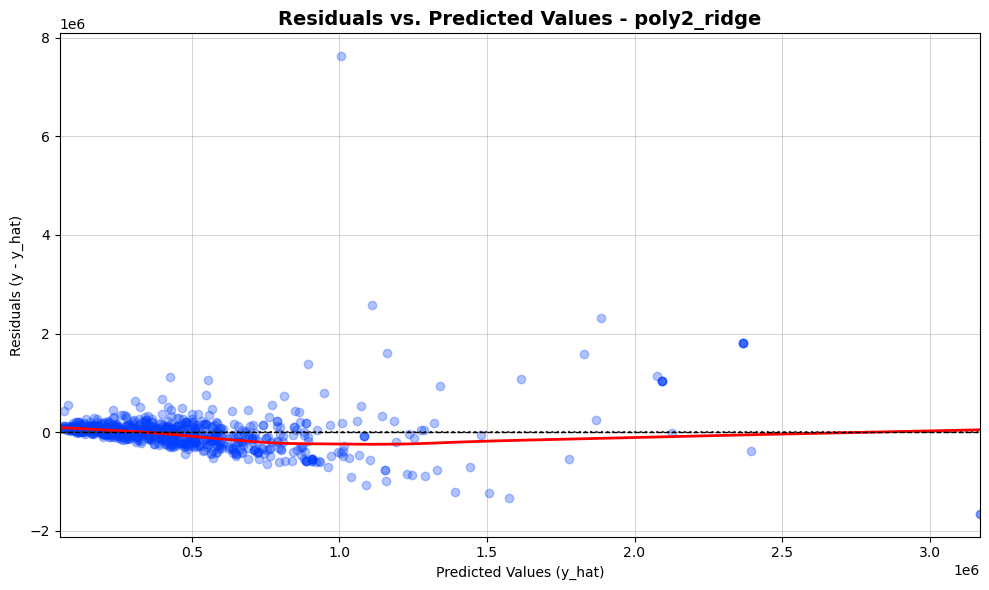

In [27]:
best_name = results.iloc[0]["Model"]
best_model = candidates[best_name]
y_pred_best = best_model.predict(X_test)

y_pred_flatten = y_pred_best.flatten()
y_true_flatten = y_test.values.flatten()

# Calculate residuals
residuals = y_true_flatten - y_pred_flatten

fig, ax = plt.subplots(figsize=(10, 6))

sns.residplot(
    x=y_pred_flatten,
    y=residuals,
    lowess=True,
    color="b",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red", "lw": 2},
    ax=ax,
)

ax.set_title(
    f"Residuals vs. Predicted Values - {best_name}", fontsize=14, fontweight="bold"
)
ax.set_xlabel("Predicted Values (y_hat)")
ax.set_ylabel("Residuals (y - y_hat)")
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.grid(True, alpha=0.4, linewidth=0.6, color="grey")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()